# Notebook 4 — Régression Linéaire

Objectif : modéliser et prédire `sleep_duration_hours` et `stress_level` avec des **modèles linéaires**.

**Outils :** Scikit-learn (LinearRegression, Ridge, Lasso) · Statsmodels (OLS avec p-values)

**Source :** `dataset_engineered.csv`

---
### Plan
1. Régression simple OLS (statsmodels) — temps d'écran → sommeil
2. Régression multiple OLS — toutes features sélectionnées
3. Vérification des hypothèses (résidus, VIF, homoscédasticité)
4. Ridge et Lasso (régularisation)
5. Évaluation et comparaison des modèles

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('dataset_engineered.csv')
print(f'Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

Dataset : 15,000 lignes × 45 colonnes


## 1. Préparation des données

In [2]:
# Features pour la régression (variables numériques de base + engineered)
FEATURES = [
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_quality_score',
    'stress_level',
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'notifications_received_per_day',
    'mental_fatigue_score',
    'age',
    'digital_load_hours',
    'stress_fatigue_index',
    'sleep_deficit_hours',
]

FEATURES_FOR_STRESS = [
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_hours',
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'notifications_received_per_day',
    'mental_fatigue_score',
    'age',
    'digital_load_hours',
    'sleep_deficit_hours',
]

df_model = df[FEATURES + ['sleep_duration_hours']].dropna()

X_sleep  = df_model[FEATURES]
y_sleep  = df_model['sleep_duration_hours']

df_stress = df[FEATURES_FOR_STRESS + ['stress_level']].dropna()
X_stress = df_stress[FEATURES_FOR_STRESS]
y_stress = df_stress['stress_level']

# Train / test split (80/20, graine fixée pour reproductibilité)
X_tr_sl, X_te_sl, y_tr_sl, y_te_sl = train_test_split(X_sleep,  y_sleep,  test_size=0.2, random_state=42)
X_tr_st, X_te_st, y_tr_st, y_te_st = train_test_split(X_stress, y_stress, test_size=0.2, random_state=42)

# Standardisation (important pour Ridge et Lasso)
scaler = StandardScaler()
X_tr_sl_s = scaler.fit_transform(X_tr_sl)
X_te_sl_s = scaler.transform(X_te_sl)

print(f'Train : {X_tr_sl.shape[0]:,}  |  Test : {X_te_sl.shape[0]:,}')

Train : 12,000  |  Test : 3,000


## 2. Régression simple (OLS statsmodels) — variable principale

**OLS = Ordinary Least Squares** (moindres carrés ordinaires). Statsmodels fournit le rapport statistique complet avec p-values et intervalles de confiance.

In [3]:
# Régression simple : daily_screen_time_hours → sleep_duration_hours
X_simple = sm.add_constant(df_model['daily_screen_time_hours'])  # Ajoute l'intercept
model_simple = sm.OLS(y_sleep, X_simple).fit()
print(model_simple.summary())

                             OLS Regression Results                             
Dep. Variable:     sleep_duration_hours   R-squared:                       0.000
Model:                              OLS   Adj. R-squared:                 -0.000
Method:                   Least Squares   F-statistic:                   0.05221
Date:                  Fri, 29 May 2026   Prob (F-statistic):              0.819
Time:                          11:58:43   Log-Likelihood:                -26876.
No. Observations:                 15000   AIC:                         5.376e+04
Df Residuals:                     14998   BIC:                         5.377e+04
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const 

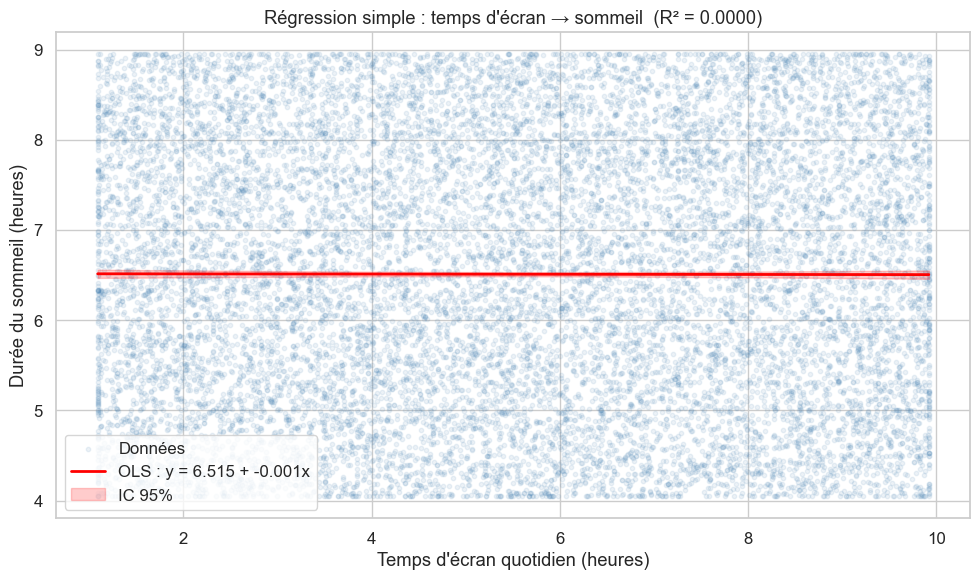

In [4]:
# Visualisation de la droite de régression simple
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_model['daily_screen_time_hours'], y_sleep, alpha=0.1, s=10, color='steelblue', label='Données')

x_line = np.linspace(df_model['daily_screen_time_hours'].min(), df_model['daily_screen_time_hours'].max(), 100)
y_line = model_simple.params[0] + model_simple.params[1] * x_line
ax.plot(x_line, y_line, color='red', linewidth=2, label=f'OLS : y = {model_simple.params[0]:.3f} + {model_simple.params[1]:.3f}x')

ax.fill_between(
    x_line,
    model_simple.get_prediction(sm.add_constant(x_line)).summary_frame()['mean_ci_lower'],
    model_simple.get_prediction(sm.add_constant(x_line)).summary_frame()['mean_ci_upper'],
    alpha=0.2, color='red', label='IC 95%'
)
ax.set_xlabel('Temps d\'écran quotidien (heures)')
ax.set_ylabel('Durée du sommeil (heures)')
ax.set_title(f'Régression simple : temps d\'écran → sommeil  (R² = {model_simple.rsquared:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Régression multiple (OLS statsmodels)

On ajoute plusieurs variables explicatives pour améliorer le pouvoir prédictif.

In [5]:
X_multi = sm.add_constant(X_sleep)
model_multi = sm.OLS(y_sleep, X_multi).fit()
print(model_multi.summary())

                             OLS Regression Results                             
Dep. Variable:     sleep_duration_hours   R-squared:                       0.980
Model:                              OLS   Adj. R-squared:                  0.980
Method:                   Least Squares   F-statistic:                 6.619e+04
Date:                  Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                          11:58:44   Log-Likelihood:                 2400.9
No. Observations:                 15000   AIC:                            -4778.
Df Residuals:                     14988   BIC:                            -4686.
Df Model:                            11                                         
Covariance Type:              nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

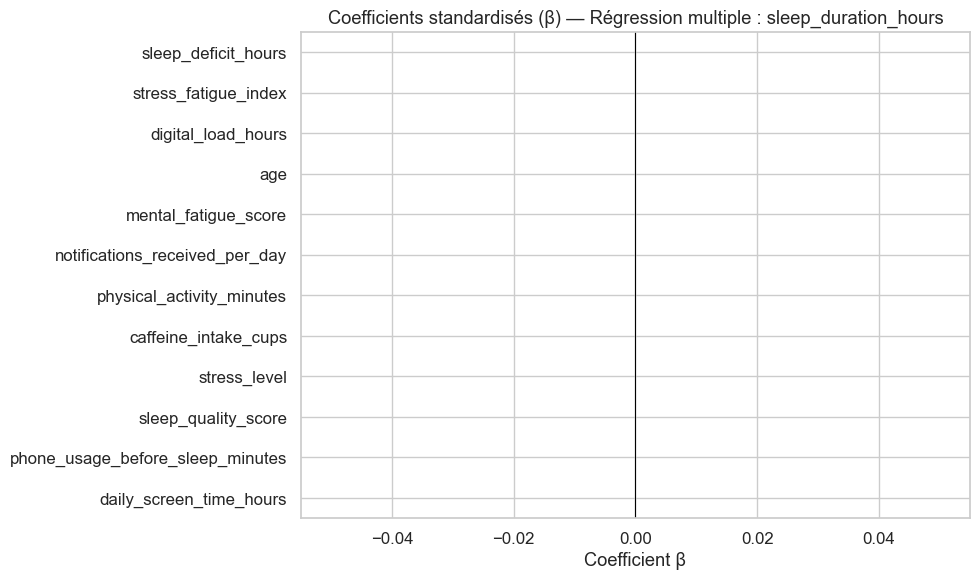

In [6]:
# Coefficients standardisés (bêta) : permettent de comparer l'influence de chaque variable
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_sleep)
y_std = (y_sleep - y_sleep.mean()) / y_sleep.std()

model_std = sm.OLS(y_std, sm.add_constant(X_std)).fit()
betas = pd.Series(model_std.params[1:], index=FEATURES).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d73027' if v < 0 else '#1a9850' for v in betas.values]
betas.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coefficients standardisés (β) — Régression multiple : sleep_duration_hours')
ax.set_xlabel('Coefficient β')
plt.tight_layout()
plt.show()

## 4. Vérification des hypothèses de la régression

La régression linéaire repose sur 4 hypothèses clés :
1. **Linéarité** — relation linéaire entre X et y
2. **Normalité des résidus** — les erreurs suivent une loi normale
3. **Homoscédasticité** — variance des erreurs constante
4. **Indépendance** — pas d'autocorrélation des erreurs (Durbin-Watson)

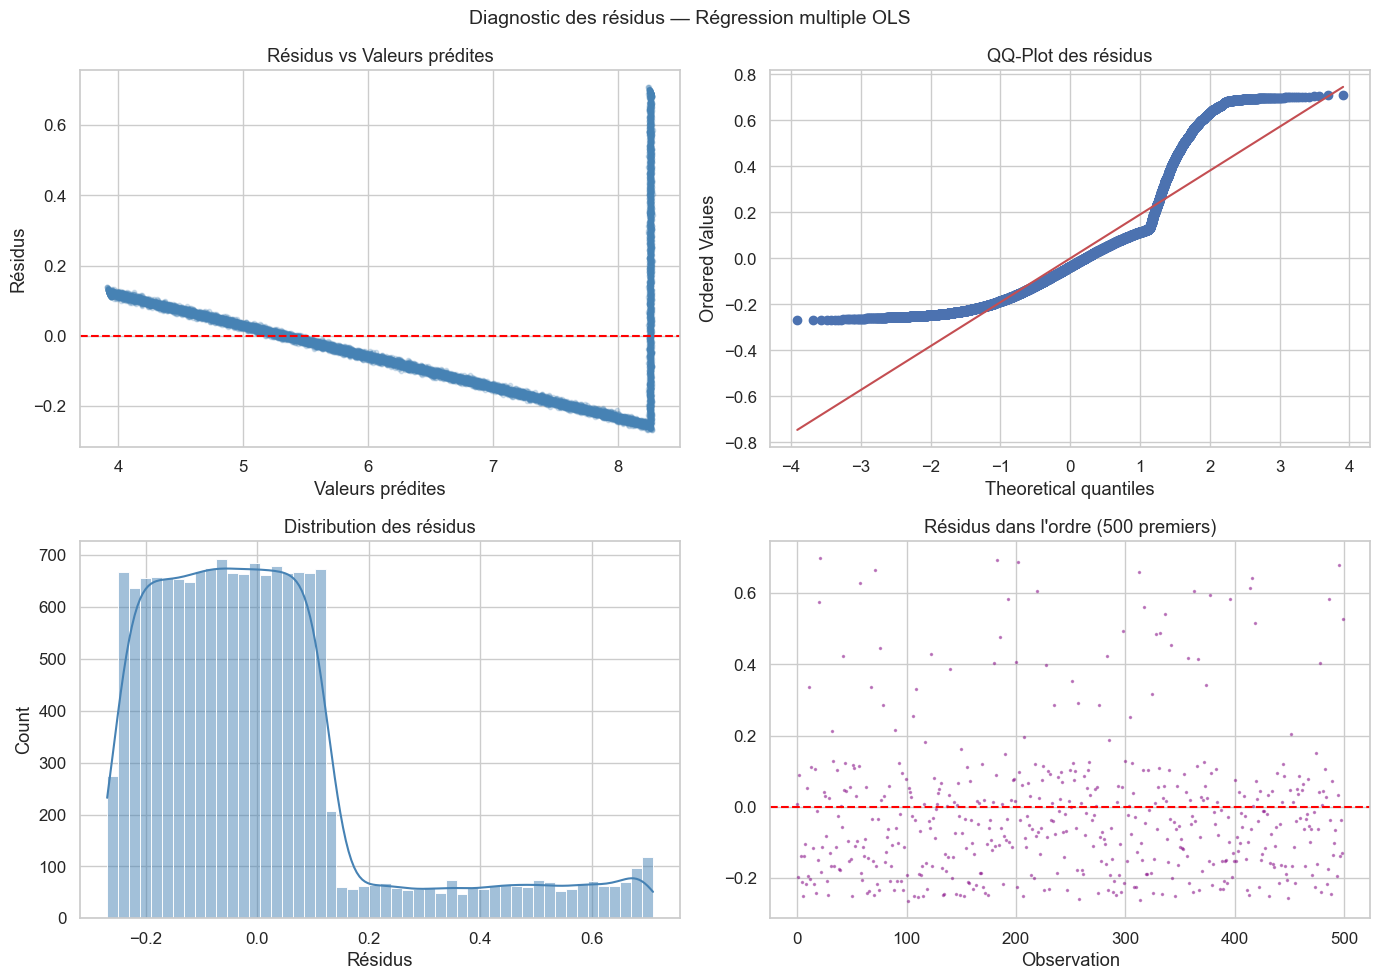

Durbin-Watson : 2.0009  (proche de 2 → pas d'autocorrélation)


In [7]:
residus = model_multi.resid
y_pred_ols = model_multi.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Résidus vs valeurs prédites (linéarité + homoscédasticité)
axes[0][0].scatter(y_pred_ols, residus, alpha=0.2, s=10, color='steelblue')
axes[0][0].axhline(0, color='red', linestyle='--')
axes[0][0].set_xlabel('Valeurs prédites')
axes[0][0].set_ylabel('Résidus')
axes[0][0].set_title('Résidus vs Valeurs prédites')

# 2. QQ-plot des résidus (normalité)
stats.probplot(residus, dist='norm', plot=axes[0][1])
axes[0][1].set_title('QQ-Plot des résidus')

# 3. Histogramme des résidus
sns.histplot(residus, kde=True, ax=axes[1][0], color='steelblue', bins=50)
axes[1][0].set_xlabel('Résidus')
axes[1][0].set_title('Distribution des résidus')

# 4. Résidus vs ordre (autocorrélation)
axes[1][1].plot(residus.values[:500], '.', alpha=0.4, color='purple', markersize=3)
axes[1][1].axhline(0, color='red', linestyle='--')
axes[1][1].set_title('Résidus dans l\'ordre (500 premiers)')
axes[1][1].set_xlabel('Observation')

plt.suptitle('Diagnostic des résidus — Régression multiple OLS', fontsize=14)
plt.tight_layout()
plt.show()

dw = durbin_watson(residus)
print(f'Durbin-Watson : {dw:.4f}  (proche de 2 → pas d\'autocorrélation)')

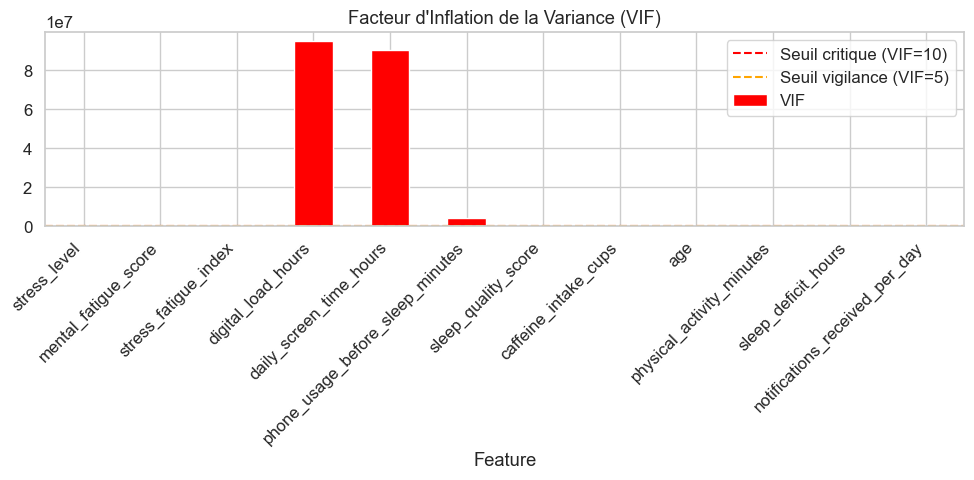

                         Feature          VIF
                    stress_level          inf
            mental_fatigue_score          inf
            stress_fatigue_index          inf
              digital_load_hours 9.483536e+07
         daily_screen_time_hours 9.022169e+07
phone_usage_before_sleep_minutes 4.446621e+06
             sleep_quality_score 4.533110e+00
            caffeine_intake_cups 1.001219e+00
                             age 1.001168e+00
       physical_activity_minutes 1.000935e+00
             sleep_deficit_hours 1.000870e+00
  notifications_received_per_day 1.000218e+00


In [8]:
# VIF — Facteur d'inflation de la variance (multicolinéarité)
# VIF > 10 : problème de multicolinéarité sérieux
vif_data = pd.DataFrame()
vif_data['Feature'] = FEATURES
vif_data['VIF'] = [variance_inflation_factor(X_multi.values, i+1) for i in range(len(FEATURES))]
vif_data = vif_data.sort_values('VIF', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['red' if v > 10 else ('orange' if v > 5 else 'steelblue') for v in vif_data['VIF']]
vif_data.set_index('Feature')['VIF'].plot(kind='bar', ax=ax, color=colors)
ax.axhline(10, color='red',    linestyle='--', label='Seuil critique (VIF=10)')
ax.axhline(5,  color='orange', linestyle='--', label='Seuil vigilance (VIF=5)')
ax.set_title('Facteur d\'Inflation de la Variance (VIF)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(vif_data.to_string(index=False))

## 5. Régression Ridge et Lasso

- **Ridge (L2)** : pénalise les gros coefficients → réduit l'overfitting, garde toutes les variables
- **Lasso (L1)** : pénalise les coefficients → met certains à zéro → sélection automatique de features

In [9]:
from sklearn.linear_model import RidgeCV, LassoCV

# RidgeCV : teste automatiquement plusieurs valeurs d'alpha
ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge.fit(X_tr_sl_s, y_tr_sl)
y_pred_ridge = ridge.predict(X_te_sl_s)

# LassoCV
lasso = LassoCV(alphas=[0.001, 0.01, 0.1, 1], cv=5, max_iter=5000)
lasso.fit(X_tr_sl_s, y_tr_sl)
y_pred_lasso = lasso.predict(X_te_sl_s)

# Régression OLS classique (non régularisée)
lr = LinearRegression()
lr.fit(X_tr_sl_s, y_tr_sl)
y_pred_lr = lr.predict(X_te_sl_s)

print(f'Alpha optimal Ridge : {ridge.alpha_}')
print(f'Alpha optimal Lasso : {lasso.alpha_:.4f}')
print(f'\nCoefficients Lasso mis à zéro : {np.sum(lasso.coef_ == 0)} / {len(lasso.coef_)}')

Alpha optimal Ridge : 0.01
Alpha optimal Lasso : 0.0010

Coefficients Lasso mis à zéro : 7 / 12


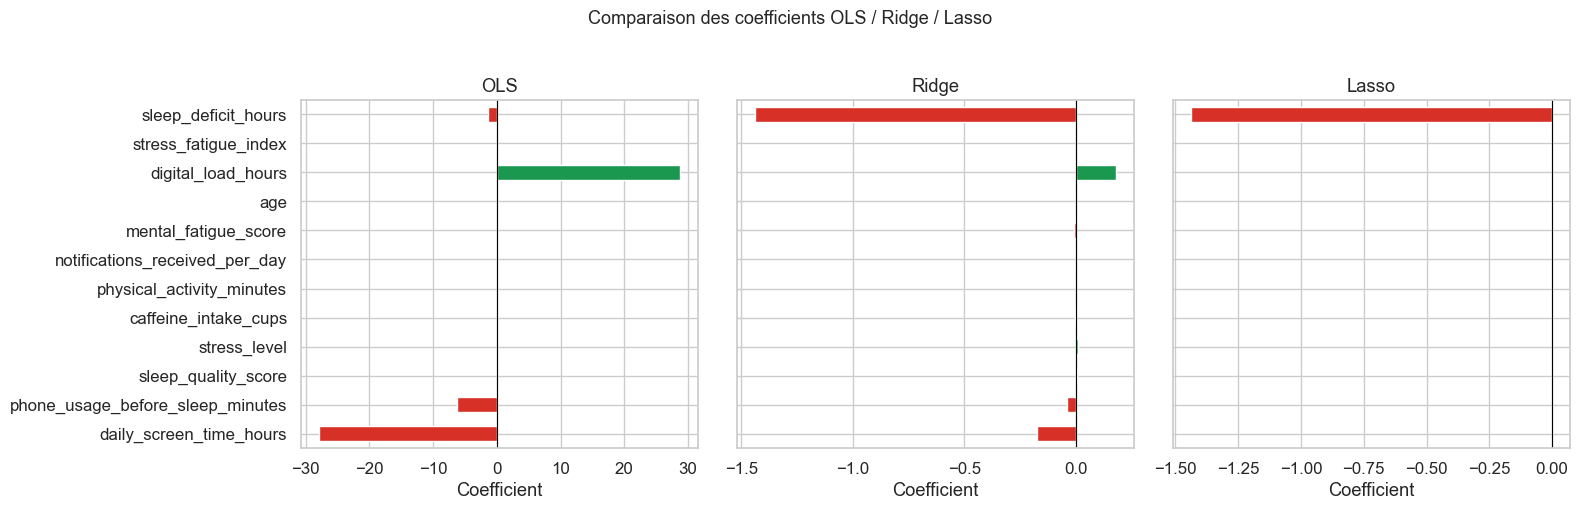

In [10]:
# Comparaison des coefficients Ridge vs Lasso
coef_df = pd.DataFrame({
    'OLS'   : lr.coef_,
    'Ridge' : ridge.coef_,
    'Lasso' : lasso.coef_,
}, index=FEATURES)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, col in zip(axes, ['OLS', 'Ridge', 'Lasso']):
    colors = ['#d73027' if v < 0 else '#1a9850' for v in coef_df[col]]
    coef_df[col].plot(kind='barh', ax=ax, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(col)
    ax.set_xlabel('Coefficient')
plt.suptitle('Comparaison des coefficients OLS / Ridge / Lasso', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Évaluation et comparaison des modèles

In [11]:
def evaluate(name, y_true, y_pred):
    return {
        'Modèle' : name,
        'RMSE'   : np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE'    : mean_absolute_error(y_true, y_pred),
        'R²'     : r2_score(y_true, y_pred),
    }

results = [
    evaluate('OLS (LinearRegression)',  y_te_sl, y_pred_lr),
    evaluate('Ridge',                   y_te_sl, y_pred_ridge),
    evaluate('Lasso',                   y_te_sl, y_pred_lasso),
]

result_df = pd.DataFrame(results).set_index('Modèle').round(4)
print('=== Métriques sur le jeu de test ===')
print(result_df.to_string())


=== Métriques sur le jeu de test ===
                          RMSE     MAE      R²
Modèle                                        
OLS (LinearRegression)  0.2136  0.1533  0.9781
Ridge                   0.2136  0.1533  0.9781
Lasso                   0.2136  0.1529  0.9781


In [12]:
# Validation croisée (5-fold) pour un score plus robuste
kf = KFold(n_splits=5, shuffle=True, random_state=42)

X_all_s = scaler.fit_transform(X_sleep)

for name, model in [('LinearRegression', LinearRegression()), ('Ridge', Ridge(alpha=ridge.alpha_)), ('Lasso', Lasso(alpha=lasso.alpha_))]:
    cv_r2 = cross_val_score(model, X_all_s, y_sleep, cv=kf, scoring='r2')
    cv_rmse = np.sqrt(-cross_val_score(model, X_all_s, y_sleep, cv=kf, scoring='neg_mean_squared_error'))
    print(f'{name:<20}  R² moyen : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}  |  RMSE moyen : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}')

LinearRegression      R² moyen : 0.9798 ± 0.0009  |  RMSE moyen : 0.2063 ± 0.0043
Ridge                 R² moyen : 0.9798 ± 0.0009  |  RMSE moyen : 0.2063 ± 0.0042
Lasso                 R² moyen : 0.9798 ± 0.0009  |  RMSE moyen : 0.2063 ± 0.0043


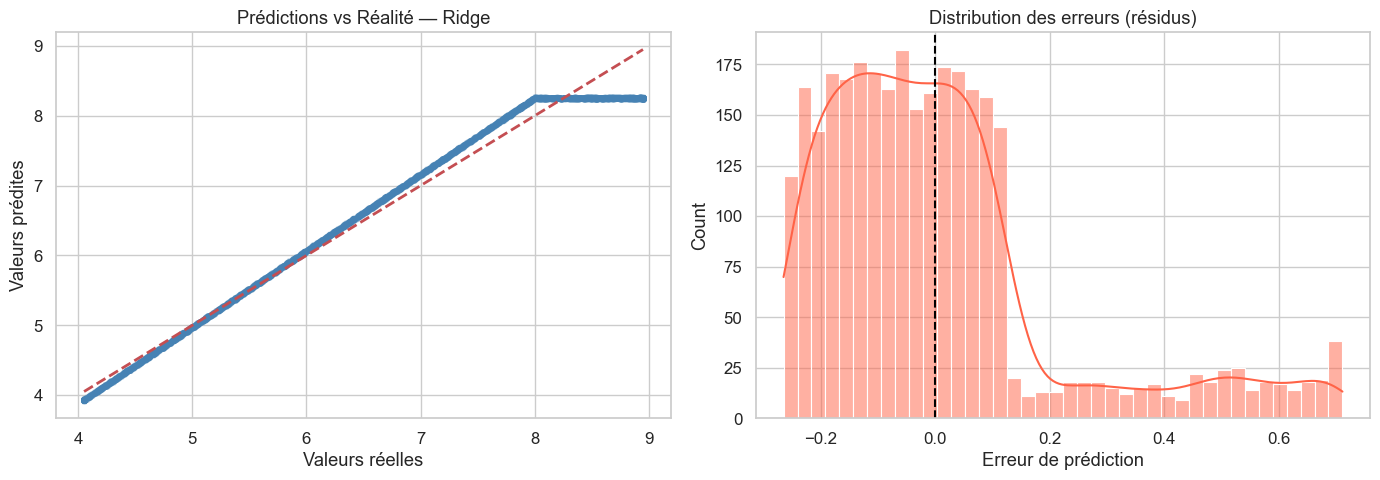

In [13]:
# Graphiques prédictions vs réalité pour le meilleur modèle
best_pred = y_pred_ridge  # Adapter selon les résultats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_te_sl, best_pred, alpha=0.3, s=15, color='steelblue')
axes[0].plot([y_te_sl.min(), y_te_sl.max()], [y_te_sl.min(), y_te_sl.max()], 'r--', lw=2)
axes[0].set_xlabel('Valeurs réelles')
axes[0].set_ylabel('Valeurs prédites')
axes[0].set_title('Prédictions vs Réalité — Ridge')

errors = y_te_sl.values - best_pred
sns.histplot(errors, kde=True, ax=axes[1], color='tomato', bins=40)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Erreur de prédiction')
axes[1].set_title('Distribution des erreurs (résidus)')

plt.tight_layout()
plt.show()

## 7. Régression sur stress_level

In [14]:
X_st_s = StandardScaler().fit_transform(X_stress)
X_tr_st_s, X_te_st_s, y_tr_st_s, y_te_st_s = train_test_split(X_st_s, y_stress, test_size=0.2, random_state=42)

lr_st    = LinearRegression().fit(X_tr_st_s, y_tr_st_s)
ridge_st = RidgeCV(alphas=[0.01,0.1,1,10,100], cv=5).fit(X_tr_st_s, y_tr_st_s)
lasso_st = LassoCV(cv=5, max_iter=5000).fit(X_tr_st_s, y_tr_st_s)

results_stress = [
    evaluate('OLS',   y_te_st_s, lr_st.predict(X_te_st_s)),
    evaluate('Ridge', y_te_st_s, ridge_st.predict(X_te_st_s)),
    evaluate('Lasso', y_te_st_s, lasso_st.predict(X_te_st_s)),
]

print('=== Prédiction de stress_level ===')
pd.DataFrame(results_stress).set_index('Modèle').round(4)

=== Prédiction de stress_level ===


,RMSE,MAE,R²
Modèle,,,
OLS,0.7191,0.5584,0.9313
Ridge,0.7191,0.5586,0.9313
Lasso,0.7192,0.5581,0.9313
